In [1]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
from torchvision import transforms 
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F

## Intro
This Notebook is based on the original DIffusion Model proposed in the [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) paper.

**Objective**
The objective of the notebook is to provide insights of the paper and be used as a guide to better understand the paper. The notebook will not dive into the derivations (though there are some great videos on Youtube). However, I will try to stick to the paper notation so it will be easier to guide.

## Forward Pass
The forward pass in the diffusion model requires no learning (no NN needed since no parameters to be learned). The idea is that noise is added with the help of linear scheduler-$\beta_{t}$ (in [OpenAI]() the scheduler parameter is trainable). \
The forward pass process is defined by Markov Chain where Gaussian noise is added according to the scheduler.

**Definitions**
* x_{0}: original image (no noise)
* t: timestep (at each timestep incremental noise is added during forward pass)
* $q(x_{1:T}|x_{0})$: Posterior that follow tha Markov Chain that Gaussian noise is gradually added 


**Useful Equations**
* $q(x_{t}|x_{t-1}) = \mathcal{N}(x_{t}; \sqrt{1-\beta_{t}}x_{t}, \beta_{t}I)$: Markov Chain with noise gradually added (determined by $\beta_{t}$)
* $q(x_{t}|x_{0}) = \mathcal{N}(x_{t}; \sqrt{\tilde{\alpha_{t}}}x_{0}, (1-\tilde{\alpha_{t}}I))$, where $\alpha_{t} = 1-\beta_{t}$ and $\tilde{\alpha_{t}} = \prod_{s=1}^{t}\alpha_{s}$: Probability distribution of noise version of the image after T steps
* $x_{t} = \sqrt{\tilde{\alpha_{t}}}x_{0} + \sqrt{1+\tilde{\alpha_{t}}}\epsilon$, where $\epsilon ~ \mathcal{N}(0, I)$: Reperametrization trick to determine the image after t steps of added noise.


In [3]:
T = 300 # timesteps


# setting up some constant values as lists (not much memory needed and faster than calculating multiple times on the go)
beta = torch.linspace(0.0001, 0.02, T)
alpha = 1. - beta
tilde_alpha = torch.cumprod(alpha,dim=0) # cumulative product 
sqrt_alpha = torch.sqrt(alpha)
sqrt_tilde_alpha = torch.sqrt(tilde_alpha)
sqrt_one_minus_tilde_alpha = torch.sqrt(1-tilde_alpha)
posteririo_var = ((1-tilde_alpha.roll(1))/(1-tilde_alpha))*beta # first entry will be ignored lated on thus no additional code is needed

In [5]:
def forward_pass_step(x0, t):
    '''
    Forward pass image x0 and generate the noisy ouput after t steps.
    Return the original noise, since it is needed in the loss function.
    '''
    
    epsilon = torch.randn_like(x0) # generate the noise matrix mathcing the x0 shape (B x 3 x 64 x 64)
    
    xt = sqrt_tilde_alpha[t].view(-1, 1, 1, 1)*x0 + sqrt_one_minus_tilde_alpha[t].view(-1, 1, 1, 1)*epsilon
    
    return xt, epsilon

## Load Images

100%|██████████| 344862509/344862509 [00:18<00:00, 18864473.03it/s]


Extracting flowers-102/102flowers.tgz to flowers-102


100%|██████████| 502/502 [00:00<00:00, 386621.49it/s]


100%|██████████| 14989/14989 [00:00<00:00, 9287697.25it/s]


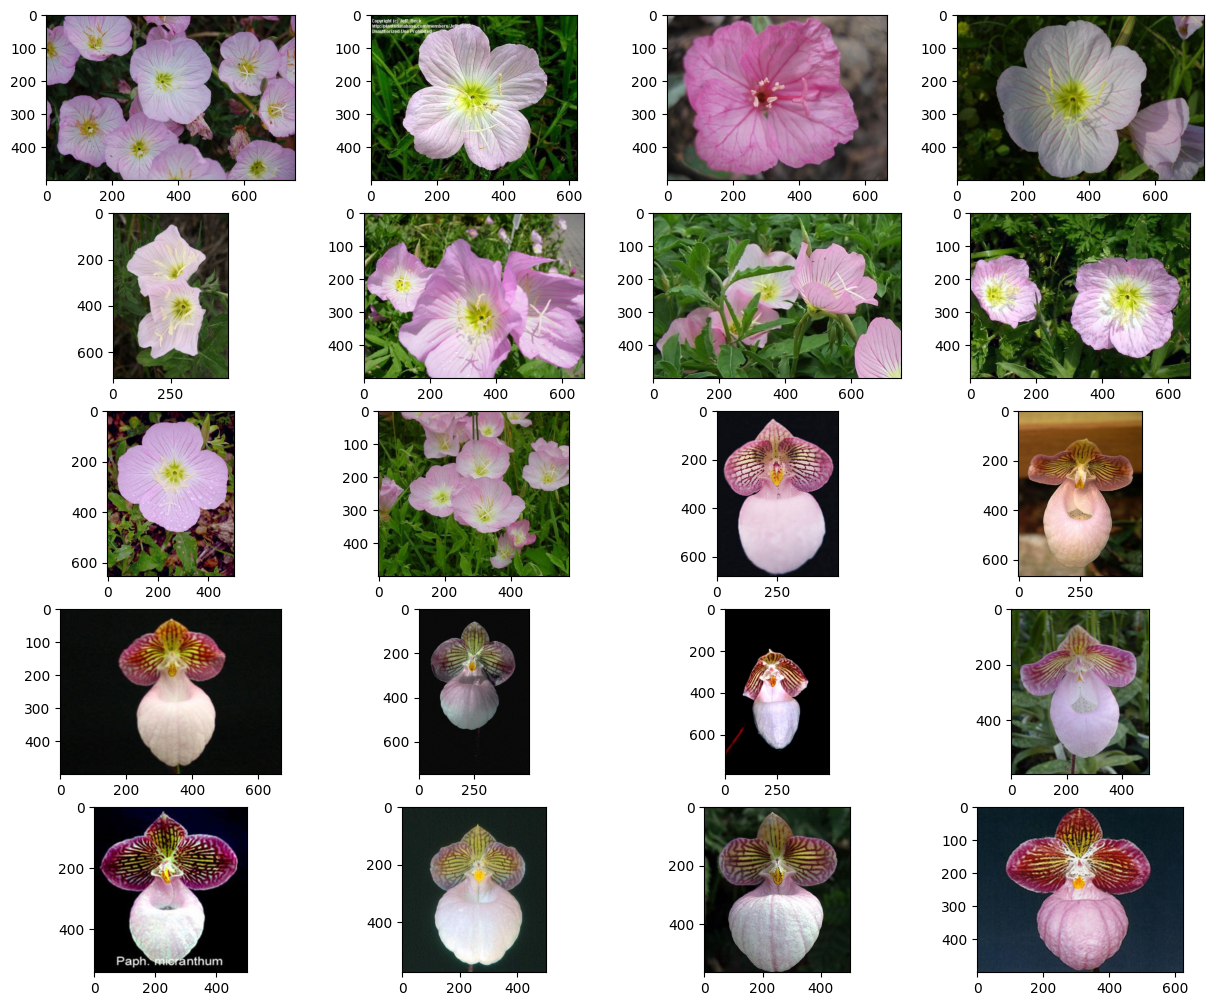

In [6]:
def show_images(datset, num_samples=20, cols=4):
    """ Plots some samples from the dataset """
    plt.figure(figsize=(15,15)) 
    for i, img in enumerate(data):
        if i == num_samples:
            break
        plt.subplot(int(num_samples/cols) + 1, cols, i + 1)
        plt.imshow(img[0])

data = torchvision.datasets.Flowers102(root=".", download=True)
show_images(data)

In [7]:
IMG_SIZE = 64
BATCH_SIZE = 128

In [8]:
def load_transformed_dataset():
    data_transforms = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), # Scales data into [0,1] 
        transforms.Lambda(lambda t: (t * 2) - 1) # Scale between [-1, 1] 
    ]
    data_transform = transforms.Compose(data_transforms)

    train = torchvision.datasets.Flowers102(root=".", download=True, 
                                         transform=data_transform)

    test = torchvision.datasets.Flowers102(root=".", download=True, 
                                         transform=data_transform, split='test')
    return torch.utils.data.ConcatDataset([train, test])
def show_tensor_image(image):
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)), # CHW to HWC
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.numpy().astype(np.uint8)),
        transforms.ToPILImage(),
    ])

    # Take first image of batch
    if len(image.shape) == 4:
        image = image[0, :, :, :] 
    plt.imshow(reverse_transforms(image))

data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [9]:
# Simulate forward diffusion
image = next(iter(dataloader))[0]

/tmp/ipykernel_33/3646654605.py:9: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, num_images+1, int(idx/stepsize) + 1)


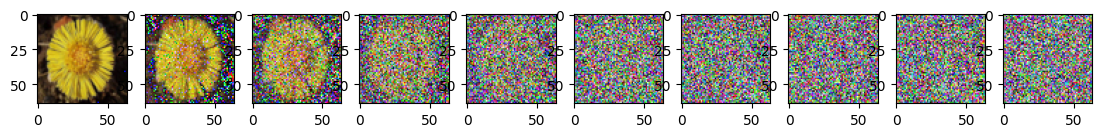

In [10]:
plt.figure(figsize=(15,15))
plt.axis('off')
num_images = 10
stepsize = int(T/num_images)

for idx in range(0, T, stepsize):
    t = torch.Tensor([idx]).type(torch.int64)
#     print(t)
    plt.subplot(1, num_images+1, int(idx/stepsize) + 1)
    img, noise = forward_pass_step(image, t)
    show_tensor_image(img)

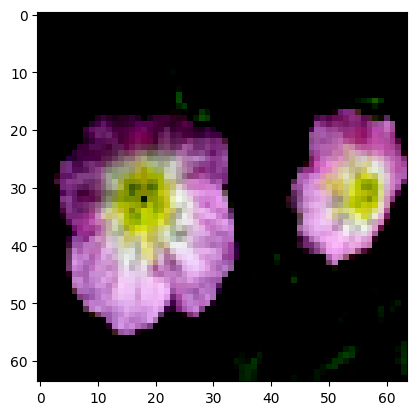

In [11]:
plt.imshow(image[1].detach().cpu().permute(1,2,0))

## Sinusoidal Positional Embedding

The following implementation is based on the following article:
https://kazemnejad.com/blog/transformer_architecture_positional_encoding/

TLDR:
...

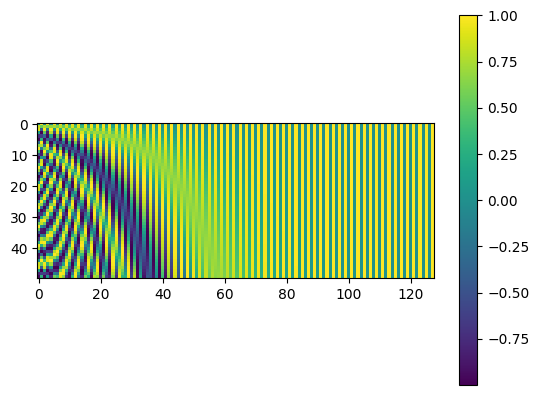

In [12]:
embedding_dim = 128
theta = 10000
timesteps = 50
embeddings_list = []

for t in range(timesteps):
    log_even_omegas= -((2*np.log10(theta))/embedding_dim) * (torch.arange(0, embedding_dim, 2)//2) # i=2k 
    log_odd_omegas= -((2*np.log10(theta))/embedding_dim) * (torch.arange(1, embedding_dim, 2)//2) # i=2k+1
        
    even_omegas = torch.pow(10, log_even_omegas)
    odd_omegas = torch.pow(10, log_odd_omegas)
    
    sin_vecs = torch.sin(even_omegas*t)
    cos_vecs = torch.cos(odd_omegas*t)
    
    embeddings_list.append(torch.stack([sin_vecs, cos_vecs]).T.reshape(-1))
    
plt.imshow(embeddings_list)
plt.colorbar()

The above is the way the embedding is generated for 1D series, such as sentences. It is used for embedding of a sentence of up to 50 words. \
The following part of the code allows to extened this concept to images (accounting for batches and image dimension)


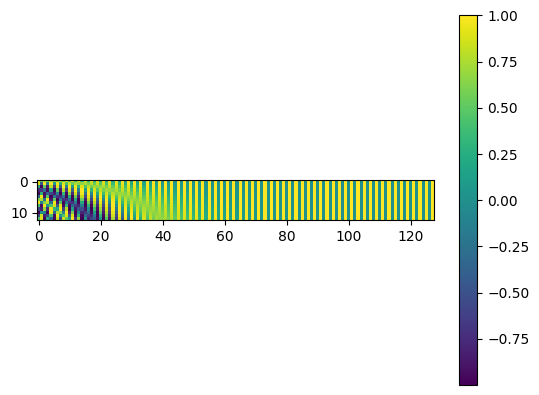

In [13]:
embedding_dim = 128
theta = 10000
t = torch.Tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]) # batch of 3 images
image_dim = 32

log_even_omegas= -((2*np.log10(theta))/embedding_dim) * (torch.arange(0, embedding_dim, 2)//2) # i=2k 
log_odd_omegas= -((2*np.log10(theta))/embedding_dim) * (torch.arange(1, embedding_dim, 2)//2) # i=2k+1

even_omegas = torch.pow(10, log_even_omegas)
odd_omegas = torch.pow(10, log_odd_omegas)

sin_vecs = torch.sin(t[:, None] * even_omegas)
cos_vecs = torch.cos(t[:, None] * odd_omegas)

embedding = torch.cat([sin_vecs, cos_vecs], -1) # in the paper, sin() and cos() are alternating but I do not see any benefit
    
final_embedding = torch.stack([sin_vecs.reshape(-1), cos_vecs.reshape(-1)]).T.reshape(-1).reshape(len(t), -1) # true embedding, as proposed by the paper  
    
plt.imshow(final_embedding)
plt.colorbar()

## U-Net model

In [14]:
class Block(nn.Module):
    def __init__(self, 
                 cin, 
                 cout,
                 embed_dim=32,
                 down=True):
        super().__init__()
        
        self.time_mlp = nn.Sequential(nn.Linear(embed_dim, cout), 
                                      nn.ReLU())
            
        if down:
            self.conv1 = nn.Conv2d(cin, cout, kernel_size=3, padding=1)
            self.transform = nn.Conv2d(cout, cout, kernel_size=4, stride=2, padding=1)
        else:
            self.conv1 = nn.Conv2d(2*cin, cout, kernel_size=3, padding=1)
            self.transform = nn.ConvTranspose2d(cout, cout, kernel_size=4, stride=2, padding=1)
        
        self.conv2 = nn.Conv2d(cout, cout, kernel_size=3, padding=1)        
        self.bnorm1 = nn.BatchNorm2d(cout)
        self.bnorm2 = nn.BatchNorm2d(cout)
        self.relu  = nn.ReLU()
    
    def forward(self, x, time_embed):
        x = self.bnorm1(self.relu(self.conv1(x)))
        t = self.time_mlp(time_embed) # Batch x cout
        t = t[:, :, None, None] # Batch x cout x 1 x 1
        x = x + t
        x = self.bnorm2(self.relu(self.conv2(x)))
        return self.transform(x)

In [15]:
# why is this nn.Module
class SinusoidalPositioningEmb(nn.Module):
    def __init__(self, orig_embed_dim):
        
        super().__init__()
        self.dim = orig_embed_dim
    
    def forward(self, time_batch, theta=10000):
        device = time_batch.device
        
        log_even_omegas= -((2*np.log10(theta))/self.dim) * (torch.arange(0, self.dim, 2)//2).to(device) # i=2k 
        log_odd_omegas= -((2*np.log10(theta))/self.dim) * (torch.arange(1, self.dim, 2)//2).to(device) # i=2k+1

        even_omegas = torch.pow(10, log_even_omegas)
        odd_omegas = torch.pow(10, log_odd_omegas)

        sin_vecs = torch.sin(time_batch[:, None] * even_omegas)
        cos_vecs = torch.cos(time_batch[:, None] * odd_omegas)

        final_embedding = torch.stack([sin_vecs.reshape(-1), cos_vecs.reshape(-1)]).T.reshape(-1).reshape(len(time_batch), -1) # true embedding, as proposed by the paper  
        
        return final_embedding

In [16]:
class DiffusionUNET(nn.Module):
    def __init__(self, 
                 channels_in=3, 
                 channels=(64, 128, 256, 512, 1024), 
                 channels_out=3, 
                 embed_dim=32):
        
        super().__init__()
        
        self.input_conv = nn.Conv2d(channels_in, channels[0], kernel_size=3, padding=1)
        
        self.downs = nn.ModuleList([Block(channels[i], channels[i+1], down=True) for i in range(len(channels))[:-1]])
        
        self.ups = nn.ModuleList([Block(channels[i], channels[i-1], down=False) for i in range(len(channels))[::-1][:-1]])
        
        self.out_conv = nn.Conv2d(channels[0], channels_out, kernel_size=3, padding=1)
        
        self.time_mlp = nn.Sequential(SinusoidalPositioningEmb(embed_dim),
                                      nn.Linear(embed_dim, embed_dim), 
                                      nn.ReLU())
    def forward(self, x, time_batch):
        t = self.time_mlp(time_batch) # Batch x EMmbedding dim
        x = self.input_conv(x)
        
        residuals = []
        
        for down in self.downs:
            x = down(x, t)
#             print(x.shape)
            residuals.append(x)
#         print('-----------------')
        for up in self.ups:
            residual = residuals.pop()
#             print('residual: {}'.format(residual.shape))
            x = torch.cat([x, residual], 1)
#             print('concat{}'.format(x.shape))
            x = up(x, t)
#             print('x{}'.format(x.shape))
        return self.out_conv(x)

$x_{t-1} = \frac{1}{\sqrt{\alpha_{t}}}\left(x_{t}-\frac{\beta_{t}}{\sqrt{1-\tilde{\alpha}}}\epsilon_{\theta}(x_{t},t)\right) + \sigma_{t}z$

where:
* $z~\mathcal{N}(0,I)$
* $\epsilon_{\theta}(x_{t}, t)$, is the learned noise

## Loss function

In [18]:
# del model

In [19]:
from torch.optim import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = DiffusionUNET()
# model = SimpleUnet()
model.to(device)
optimizer = Adam(model.parameters(), lr=0.001)
epochs=100
img_size = 64
interval = 30

In [20]:
from tqdm import tqdm

In [22]:
@torch.no_grad()
def generate_output(x_t, t):
    pred_noise = model(x_t, t)
    z = torch.randn_like(x_t)
    t = int(torch.squeeze(t))
    if t:
        x_t_1 = (1/sqrt_alpha[t])*(x_t-(beta[t]/sqrt_one_minus_tilde_alpha[t])*pred_noise) + torch.sqrt(posteririo_var[t])*z
        return x_t_1
    else:
        x_t_1 = (1/sqrt_alpha[t])*(x_t-(beta[t]/sqrt_one_minus_tilde_alpha[t])*pred_noise)
    return x_t_1

In [23]:
def get_loss(model, x_0, t):
    x_noisy, noise = forward_pass_step(x_0, t.to('cpu'))
    noise_pred = model(x_noisy.to(device), t.to(device))
    return F.l1_loss(noise.to(device), noise_pred)

0it [00:00, ?it/s]

Epoch 0 | step 000 Loss: 0.8054115176200867 


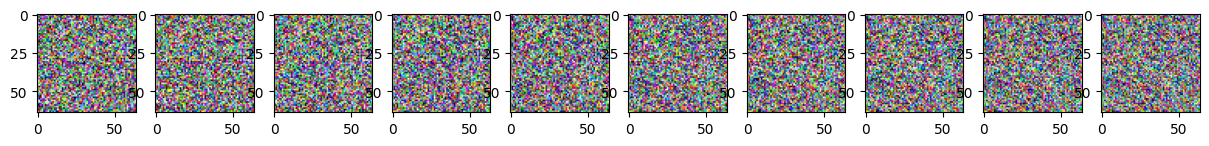

56it [00:55,  1.00it/s]
56it [00:50,  1.11it/s]
56it [00:52,  1.07it/s]
56it [00:51,  1.08it/s]
56it [00:52,  1.08it/s]
0it [00:00, ?it/s]

Epoch 5 | step 000 Loss: 0.20694869756698608 


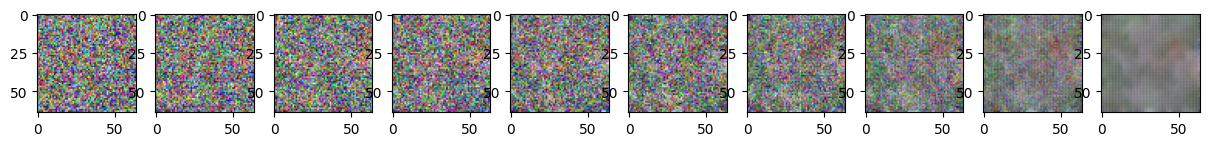

56it [00:56,  1.01s/it]
56it [00:52,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:52,  1.07it/s]
56it [00:52,  1.07it/s]
0it [00:00, ?it/s]

Epoch 10 | step 000 Loss: 0.17819182574748993 


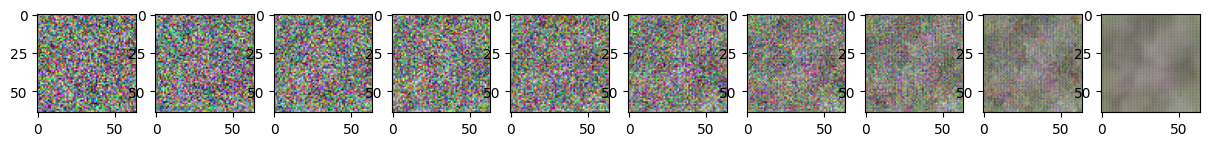

56it [00:56,  1.01s/it]
56it [00:52,  1.08it/s]
56it [00:52,  1.07it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 15 | step 000 Loss: 0.1765851229429245 


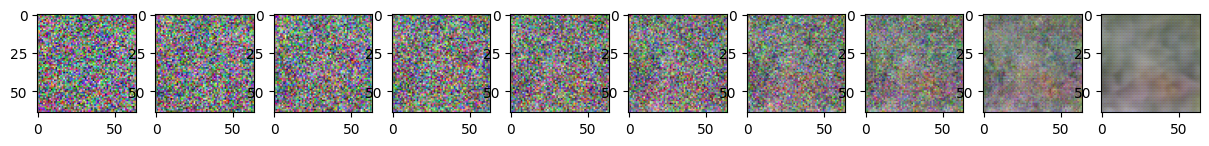

56it [00:56,  1.01s/it]
56it [00:52,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:52,  1.08it/s]
56it [00:52,  1.08it/s]
0it [00:00, ?it/s]

Epoch 20 | step 000 Loss: 0.1759236752986908 


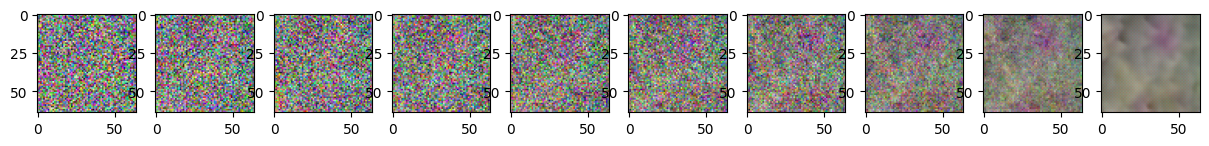

56it [00:56,  1.01s/it]
56it [00:52,  1.07it/s]
56it [00:52,  1.07it/s]
56it [00:52,  1.08it/s]
56it [00:52,  1.08it/s]
0it [00:00, ?it/s]

Epoch 25 | step 000 Loss: 0.1595112830400467 


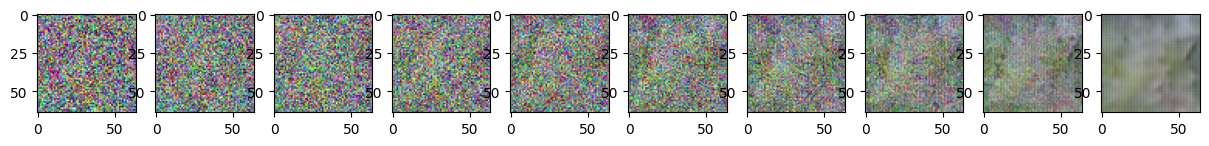

56it [00:56,  1.00s/it]
56it [00:52,  1.07it/s]
56it [00:52,  1.07it/s]
56it [00:52,  1.07it/s]
56it [00:52,  1.07it/s]
0it [00:00, ?it/s]

Epoch 30 | step 000 Loss: 0.1568664312362671 


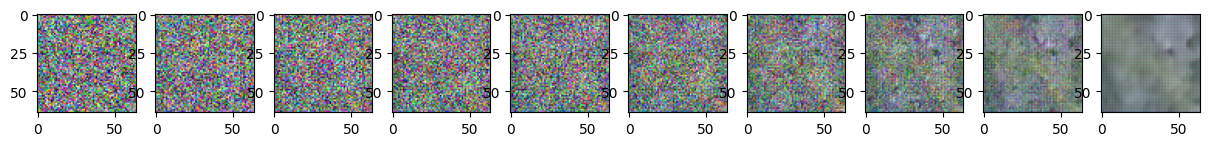

56it [00:56,  1.00s/it]
56it [00:52,  1.07it/s]
56it [00:52,  1.08it/s]
56it [00:52,  1.08it/s]
56it [00:52,  1.08it/s]
0it [00:00, ?it/s]

Epoch 35 | step 000 Loss: 0.17908847332000732 


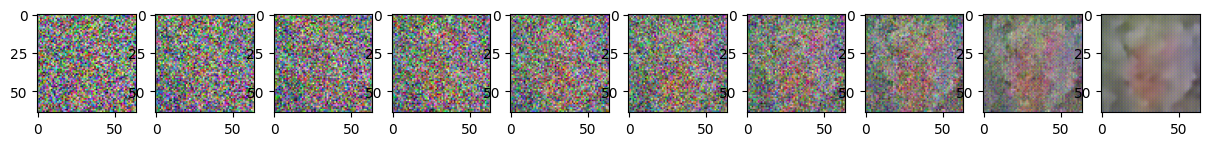

56it [00:55,  1.00it/s]
56it [00:52,  1.08it/s]
56it [00:52,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:52,  1.08it/s]
0it [00:00, ?it/s]

Epoch 40 | step 000 Loss: 0.170009046792984 


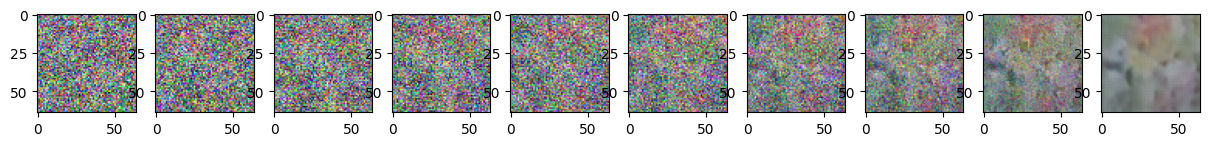

56it [00:56,  1.01s/it]
56it [00:52,  1.07it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 45 | step 000 Loss: 0.16232183575630188 


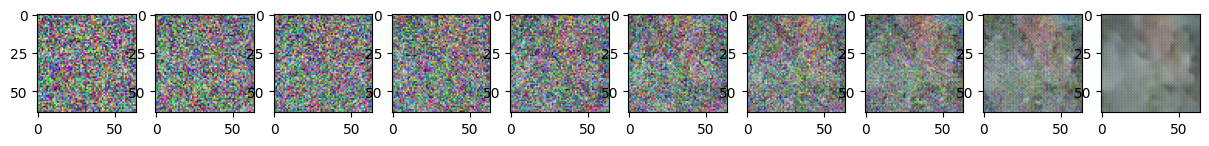

56it [00:55,  1.00it/s]
56it [00:52,  1.08it/s]
56it [00:52,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 50 | step 000 Loss: 0.15717297792434692 


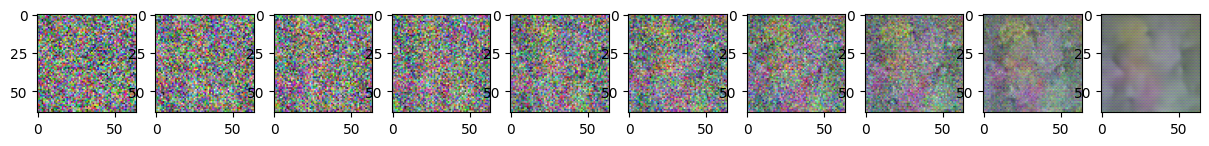

56it [00:56,  1.00s/it]
56it [00:52,  1.07it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 55 | step 000 Loss: 0.17835530638694763 


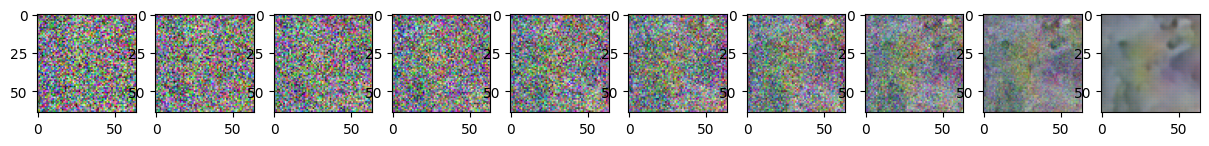

56it [00:55,  1.00it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 60 | step 000 Loss: 0.1993771493434906 


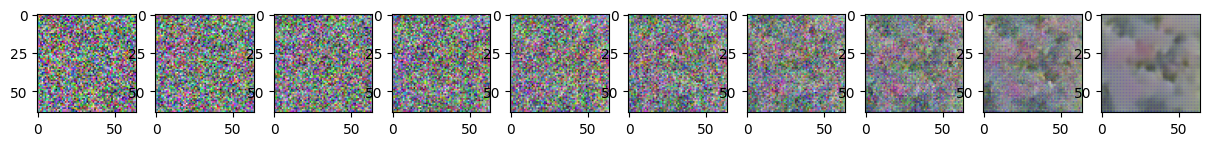

56it [00:55,  1.00it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 65 | step 000 Loss: 0.20663373172283173 


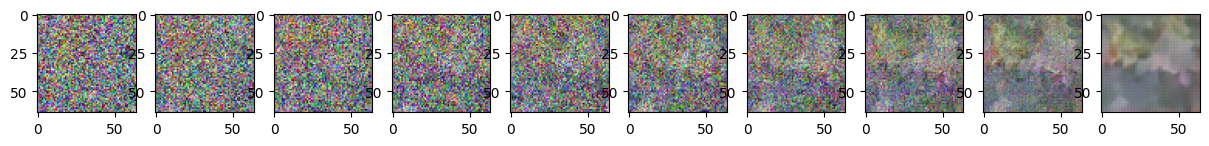

56it [00:55,  1.01it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 70 | step 000 Loss: 0.16121427714824677 


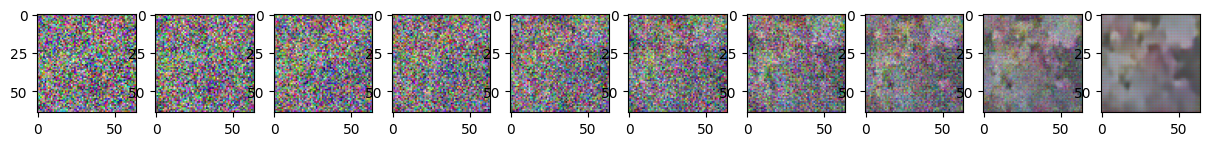

56it [00:56,  1.00s/it]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 75 | step 000 Loss: 0.16350772976875305 


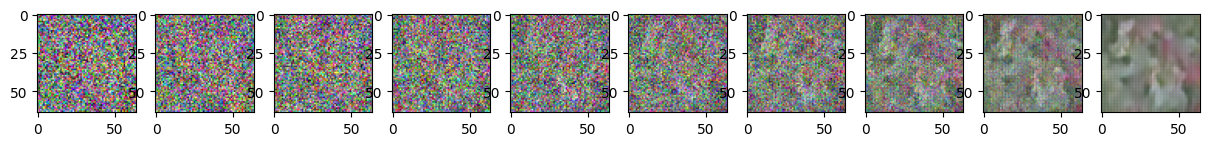

56it [00:55,  1.00it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 80 | step 000 Loss: 0.1562294363975525 


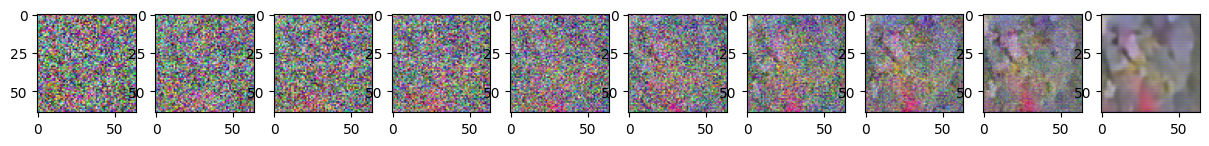

56it [00:56,  1.01s/it]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 85 | step 000 Loss: 0.1660146564245224 


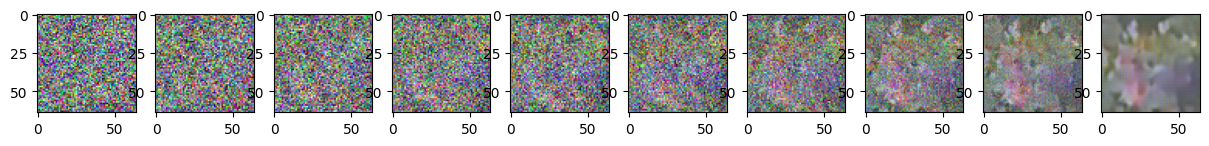

56it [00:56,  1.00s/it]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 90 | step 000 Loss: 0.14751699566841125 


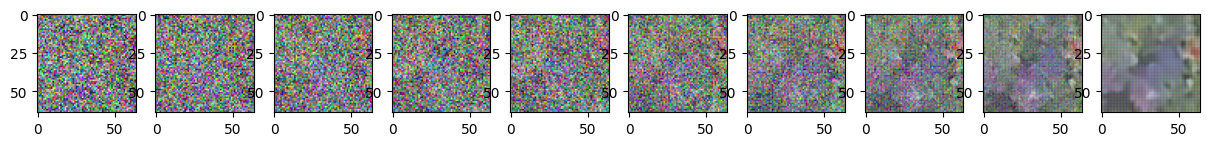

56it [00:56,  1.00s/it]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
0it [00:00, ?it/s]

Epoch 95 | step 000 Loss: 0.15435878932476044 


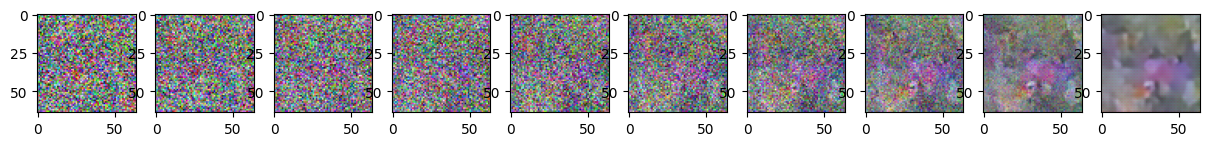

56it [00:55,  1.00it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]
56it [00:51,  1.08it/s]


In [25]:
from torch.optim import Adam
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
optimizer = Adam(model.parameters(), lr=0.001)
epochs = 100 # Try more!

for epoch in range(epochs):
    for step, batch in tqdm(enumerate(dataloader)):
        optimizer.zero_grad()

        t = torch.randint(0, T, (BATCH_SIZE,), device=device).long()
        loss = get_loss(model, batch[0], t)
        loss.backward()
        optimizer.step()

        if epoch % 5 == 0 and step == 0:
            print(f"Epoch {epoch} | step {step:03d} Loss: {loss.item()} ")
            count=1
            noisy_input = torch.randn([1, 3, img_size, img_size]).to(device)
            plt.figure(figsize=(15, 10))
            for i in range(T)[::-1]:
                i = torch.unsqueeze(torch.Tensor([i]), 0).to(device)
                noisy_input = generate_output(noisy_input, i)
                noisy_input = torch.clamp(noisy_input, -1.0, 1.0)
                if not i%interval:
                    plt.subplot(1, T//interval, count)
                    show_tensor_image(torch.squeeze(noisy_input).detach().cpu())
#                     plt.imshow(torch.squeeze(noisy_input).detach().cpu().permute(1,2,0))
                    count+=1
            plt.show()
#         if epoch % 5 == 0 and step == 0:
#             print(f"Epoch {epoch} | step {step:03d} Loss: {loss.item()} ")
#             sample_plot_image()